# 5.5 Alternating synthetic recovery

This notebook summarizes `scripts/5_5_alternating_synthetic_recovery.sh`. It treats a completed JSONL file as one seed-level observation. Partial files remain in the run inventory but are excluded from means and error bars. Error bars are $\pm1$ SEM across the completed, de-duplicated seeds.

The calibration panel reports each final learned physical scalar as a ratio to its known simulator value: $1$ is exact recovery.

In [24]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 8,
    'axes.labelsize': 8, 'axes.titlesize': 9,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 600,
})

ROOT = Path.cwd().resolve()
if not (ROOT / 'derived').exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / 'derived/results/alternating_synthetic_recovery'
FIGURE_DIR = ROOT / 'derived/results/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TOPOLOGIES = ['ring', 'grid', 'torus', 'doorway', 'swisscheese']
TOPOLOGY_LABELS = {'ring': 'Ring', 'grid': 'Grid', 'torus': 'Torus', 'doorway': 'Double slit', 'swisscheese': 'Swiss cheese'}
DYNAMICS = ['diffusion', 'wave']
DYNAMICS_LABELS = {'diffusion': 'Diffusion', 'wave': 'Wave'}

# Set this tuple to another completed schedule if the directory retains old runs.
SELECTED_SCHEDULE = (50, 10, 4)  # topology epochs, physical epochs, cycles


def read_final_jsonl(path: Path) -> dict:
    # JSONL is append-only; reading only the final record keeps this notebook fast.
    final_line = path.read_bytes().rstrip().rsplit(b'\n', 1)[-1]
    return json.loads(final_line)

def parse_name(path: Path) -> tuple[str, str]:
    match = re.match(r'alternatingsynth_(diffusion|wave)_(ring|grid|torus|doorway|swisscheese)_', path.stem)
    if match is None:
        raise ValueError(f'Unrecognized result filename: {path.name}')
    return match.group(1), match.group(2)

def schedule_from_row(row: dict) -> tuple[int, int, int]:
    cfg = row['model_cfg']
    return (
        int(cfg['fnn_alternating_topology_epochs']),
        int(cfg['fnn_alternating_physical_epochs']),
        int(cfg['fnn_alternating_cycles']),
    )

def expected_epochs(row: dict) -> int:
    topology_epochs, physical_epochs, cycles = schedule_from_row(row)
    scalar_count = 3 if int(row['model_cfg']['fnn_order']) == 1 else 4
    return topology_epochs + cycles * (topology_epochs + scalar_count * physical_epochs)

status_rows, final_rows = [], []
for path in sorted(RESULTS_DIR.glob('alternatingsynth_*.jsonl')):
    last = read_final_jsonl(path)
    dynamic, topology = parse_name(path)
    expected = expected_epochs(last)
    schedule = schedule_from_row(last)
    status_rows.append({
        'source_file': path.name, 'path': path, 'modified': path.stat().st_mtime,
        'dynamic': dynamic, 'topology': topology, 'seed': int(last['seed']),
        'logged_epochs': int(last['epoch']), 'expected_epochs': expected,
        'complete': int(last['epoch']) >= expected,
        'topology_epochs': schedule[0], 'physical_epochs': schedule[1], 'cycles': schedule[2],
    })
    final_rows.append({**pd.json_normalize(last, sep='.').iloc[0].to_dict(),
                       'source_file': path.name, 'dynamic': dynamic, 'topology': topology})

run_status = pd.DataFrame(status_rows)
final_records = pd.DataFrame(final_rows)
if run_status.empty:
    raise FileNotFoundError(f'No alternating synthetic recovery JSONL files found in {RESULTS_DIR}')

schedule_inventory = (run_status.groupby(['topology_epochs', 'physical_epochs', 'cycles'], as_index=False)
    .agg(files=('source_file', 'size'), completed=('complete', 'sum'), max_epoch=('logged_epochs', 'max'))
    .sort_values(['topology_epochs', 'physical_epochs', 'cycles']))
display(schedule_inventory)

selected = run_status.loc[
    (run_status[['topology_epochs', 'physical_epochs', 'cycles']] == SELECTED_SCHEDULE).all(axis=1)
].copy()
if selected.empty:
    raise ValueError(f'Selected schedule {SELECTED_SCHEDULE} is not available; choose one above.')

# A restarted run may leave two files for the same dynamic/topology/seed. Keep the latest.
canonical = (selected.sort_values('modified')
    .drop_duplicates(['dynamic', 'topology', 'seed'], keep='last')
    .sort_values(['dynamic', 'topology', 'seed']))
duplicates = selected.loc[~selected.source_file.isin(canonical.source_file)]
completed_sources = canonical.loc[canonical.complete, 'source_file']
final = final_records.loc[final_records.source_file.isin(completed_sources)].copy()

print(f'Using {len(final)} completed canonical runs from {len(canonical)} current runs; {len(duplicates)} older duplicate(s) ignored.')
display(canonical[['dynamic', 'topology', 'seed', 'logged_epochs', 'expected_epochs', 'complete', 'source_file']])


In [25]:
def summarize(frame: pd.DataFrame, value: str, by: list[str]) -> pd.DataFrame:
    out = frame.groupby(by, as_index=False)[value].agg(['mean', 'std', 'count']).reset_index()
    out['sem'] = out['std'].fillna(0.0) / np.sqrt(out['count'])
    return out

METRICS = {
    'test.force_mse': 'Test force MSE',
    'test.mrr': 'Test MRR',
    'test.event_auroc': 'Test event AUROC',
    'test.event_auprc': 'Test event AUPRC',
    'recovery.topology_auc': 'Topology AUROC',
    'recovery.topology_f1': 'Topology F1',
}
for metric in METRICS:
    final[metric] = pd.to_numeric(final.get(metric), errors='coerce')

metric_summary = pd.concat([
    summarize(final, metric, ['dynamic', 'topology']).assign(metric=label)
    for metric, label in METRICS.items()
], ignore_index=True)
display(metric_summary.pivot(index=['dynamic', 'topology'], columns='metric', values=['mean', 'sem', 'count']).round(4))


mean                                    \
metric                Test MRR Test event AUPRC Test event AUROC   
dynamic   topology                                                 
diffusion doorway       0.7231           0.9006           0.8975   
          grid          0.7178           0.8810           0.8810   
          ring          0.7458           0.9239           0.9246   
          swisscheese   0.7432           0.9200           0.9159   
          torus         0.7063           0.8841           0.8848   
wave      doorway       0.7844           0.9296           0.9300   
          grid          0.7527           0.9165           0.9166   
          ring          0.7549           0.9330           0.9388   
          swisscheese   0.7533           0.9160           0.9167   
          torus         0.6978           0.8985           0.8963   

                                                                     sem  \
metric                Test force MSE Topology AUROC Topology F1 Test MRR   
dynamic   topology                                                         
diffusion doorway             0.0000         0.9462      0.7618   0.0410   
          grid                0.0001         0.9305      0.7731   0.0557   
          ring                0.0000         0.9607      0.6339   0.0533   
          swisscheese         0.0001         0.9356      0.4106   0.0363   
          torus               0.0001         0.9384      0.7943   0.0549   
wave      doorway             0.0001         0.9494      0.7774   0.0280   
          grid                0.0004         0.9525      0.7835   0.0327   
          ring                0.0002         0.9781      0.7150   0.0642   
          swisscheese         0.0001         0.9470      0.4343   0.0466   
          torus               0.0002         0.9411      0.7826   0.0458   

                                                                        \
metric                Test event AUPRC Test event AUROC Test force MSE   
dynamic   topology                                                       
diffusion doorway               0.0203           0.0219         0.0000   
          grid                  0.0240           0.0300         0.0000   
          ring                  0.0231           0.0241         0.0000   
          swisscheese           0.0102           0.0107         0.0000   
          torus                 0.0183           0.0232         0.0000   
wave      doorway               0.0149           0.0143         0.0000   
          grid                  0.0179           0.0154         0.0003   
          ring                  0.0170           0.0171         0.0001   
          swisscheese           0.0217           0.0203         0.0001   
          torus                 0.0213           0.0208         0.0002   

                                                    count                   \
metric                Topology AUROC Topology F1 Test MRR Test event AUPRC   
dynamic   topology                                                           
diffusion doorway             0.0059      0.0464      5.0              5.0   
          grid                0.0100      0.0429      5.0              5.0   
          ring                0.0070      0.0760      5.0              5.0   
          swisscheese         0.0091      0.0388      5.0              5.0   
          torus               0.0066      0.0350      5.0              5.0   
wave      doorway             0.0058      0.0443      5.0              5.0   
          grid                0.0042      0.0356      5.0              5.0   
          ring                0.0046      0.0600      5.0              5.0   
          swisscheese         0.0092      0.0351      5.0              5.0   
          torus               0.0072      0.0283      5.0              5.0   

                                                                      \
metric                Test event AUROC Test force MSE Topology AUROC   
dynamic   topology            

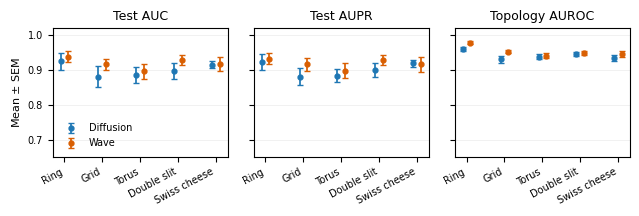

/home/tweninge/projects/ift/derived/results/figures/alternating_synthetic_recovery_performance.pdf


In [37]:
plot_metrics = [
    ('test.event_auroc', 'Test AUC'),
    ('test.event_auprc', 'Test AUPR'),
    ('recovery.topology_auc', 'Topology AUROC'),
]
fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.2), sharex=True, sharey=True)
x = np.arange(len(TOPOLOGIES))
for ax, (metric, label) in zip(axes.ravel(), plot_metrics):
    summary = summarize(final.dropna(subset=[metric]), metric, ['dynamic', 'topology'])
    for dynamic, color, offset in [('diffusion', '#1f77b4', -.10), ('wave', '#d95f02', .10)]:
        subset = summary.loc[summary.dynamic == dynamic].set_index('topology').reindex(TOPOLOGIES)
        ax.errorbar(x + offset, subset['mean'], yerr=subset['sem'], color=color, marker='o',
                    markersize=3.5, capsize=2, linewidth=1.25, linestyle='none', label=DYNAMICS_LABELS[dynamic])
    ax.set_title(label)
    ax.grid(axis='y', alpha=.22, linewidth=.55)
    ax.set_xticks(x, [TOPOLOGY_LABELS[topology] for topology in TOPOLOGIES], rotation=28, ha='right')
    ax.set_ylim(.65, 1.02)
axes[0].set_ylabel('Mean $\pm$ SEM')
axes[0].legend(frameon=False, loc='lower left')
fig.tight_layout()
performance_path = FIGURE_DIR / 'alternating_synthetic_recovery_performance.pdf'
fig.savefig(performance_path, bbox_inches='tight')
plt.show()
print(performance_path)


In [21]:
PARAMETERS = {
    'dt': ('model_cfg.fnn_dt', 'parameter_trace.learned_dt', 'parameter_trace.true_dt', r'$\Delta t / \Delta t^\star$', '#1f77b4'),
    'gamma': ('model_cfg.fnn_gamma_init', 'parameter_trace.learned_gamma', 'parameter_trace.true_gamma', r'$\gamma / \gamma^\star$', '#d95f02'),
    'omega': ('model_cfg.fnn_omega_init', 'parameter_trace.learned_omega', 'parameter_trace.true_omega', r'$\omega / \omega^\star$', '#c06c9f'),
    'force_scale': ('model_cfg.fnn_force_scale_init', 'parameter_trace.learned_force_scale', 'parameter_trace.true_force_scale', r'$s / s^\star$', '#009e73'),
}
PARAMETERS_BY_DYNAMIC = {'diffusion': ['dt', 'gamma', 'force_scale'], 'wave': ['dt', 'gamma', 'omega', 'force_scale']}

calibration_rows = []
for _, row in final.iterrows():
    for parameter in PARAMETERS_BY_DYNAMIC[row.dynamic]:
        initial_column, final_column, truth_column, label, color = PARAMETERS[parameter]
        truth = float(row[truth_column])
        calibration_rows.append({
            'dynamic': row.dynamic, 'topology': row.topology, 'seed': row.seed, 'parameter': parameter,
            'label': label, 'color': color, 'true_value': truth,
            'initial_value': float(row[initial_column]), 'final_value': float(row[final_column]),
            'initial_ratio': float(row[initial_column]) / truth,
            'final_ratio': float(row[final_column]) / truth,
        })
calibration = pd.DataFrame(calibration_rows)

calibration_summary = pd.concat([
    summarize(calibration, column, ['dynamic', 'topology', 'parameter']).assign(stage=stage)
    for column, stage in [('initial_ratio', 'initialized'), ('final_ratio', 'final')]
], ignore_index=True)
display(calibration_summary.pivot(index=['dynamic', 'topology', 'parameter'], columns='stage', values=['mean', 'sem', 'count']).round(3))

physical_values_summary = pd.concat([
    summarize(calibration, column, ['dynamic', 'topology', 'parameter']).assign(stage=stage)
    for column, stage in [('true_value', 'generator'), ('initial_value', 'initialized'), ('final_value', 'final')]
], ignore_index=True)
display(physical_values_summary.pivot(index=['dynamic', 'topology', 'parameter'], columns='stage', values=['mean', 'sem', 'count']).round(4))


mean                sem             count  \
stage                              final initialized  final initialized final   
dynamic   topology    parameter                                                 
diffusion doorway     dt           1.111       1.158  0.151       0.165   5.0   
                      force_scale  0.953       1.003  0.156       0.188   5.0   
                      gamma        1.135       1.093  0.214       0.215   5.0   
          grid        dt           1.031       1.239  0.172       0.263   5.0   
                      force_scale  0.960       1.108  0.185       0.249   5.0   
                      gamma        0.915       0.827  0.154       0.133   5.0   
          ring        dt           1.047       1.100  0.179       0.200   5.0   
                      force_scale  1.114       1.149  0.183       0.218   5.0   
                      gamma        1.049       0.971  0.239       0.248   5.0   
          swisscheese dt           1.054       1.041  0.085       0.257   5.0   
                      force_scale  0.905       0.850  0.048       0.084   5.0   
                      gamma        1.077       0.968  0.255       0.170   5.0   
          torus       dt           1.303       1.410  0.179       0.202   5.0   
                      force_scale  0.779       0.853  0.099       0.105   5.0   
                      gamma        0.940       0.897  0.145       0.139   5.0   
wave      doorway     dt           0.929       0.805  0.081       0.113   5.0   
                      force_scale  1.154       1.137  0.209       0.233   5.0   
                      gamma        1.402       1.138  0.204       0.164   5.0   
                      omega        1.296       1.146  0.151       0.235   5.0   
          grid        dt           1.110       1.065  0.130       0.250   5.0   
                      force_scale  1.048       1.068  0.214       0.240   5.0   
                      gamma        1.284       1.074  0.169       0.236   5.0   
                      omega        1.090       0.917  0.172       0.147   5.0   
          ring        dt           1.131       1.548  0.083       0.153   5.0   
                      force_scale  1.034       1.329  0.134       0.158   5.0   
                      gamma        1.751       1.233  0.389       0.281   5.0   
                      omega        1.168       0.998  0.185       0.223   5.0   
          swisscheese dt           1.065       1.110  0.119       0.234   5.0   
                      force_scale  1.089       1.156  0.235       0.262   5.0   
                      gamma        1.523       1.199  0.207       0.097   5.0   
                      omega        1.345       1.222  0.184       0.161   5.0   
          torus       dt           1.008       1.121  0.097       0.247   5.0   
                      force_scale  1.276       1.425  0.138       0.259   5.0   
                      gamma        1.540       1.129  0.359       0.240   5.0   
                      omega        1.552       1.337  0.186       0.207   5.0   

                                               
stage                             initialized  
dynamic   topology    parameter                
diffusion doorway     dt                  5.0  
                      force_scale         5.0  
                      gamma               5.0  
          grid        dt                  5.0  
                      force_scale         5.0  
                      gamma               5.0  
          ring        dt                  5.0  
                      force_scale         5.0  
                      gamma               5.0  
          swisscheese dt                  5.0  
                      force_scale         5.0  
                      gamma               5.0  
          torus       dt                  5.0  
                      force_scale         5.0  
                      gamma               5.0  
wave      doorway     dt                  5.0  
                      force_scale         5.0

mean                           sem  \
stage                               final generator initialized   final   
dynamic   topology    parameter                                           
diffusion doorway     dt           0.1111      0.10      0.1158  0.0151   
                      force_scale  0.7624      0.80      0.8024  0.1249   
                      gamma        0.1702      0.15      0.1640  0.0322   
          grid        dt           0.1031      0.10      0.1239  0.0172   
                      force_scale  0.7682      0.80      0.8863  0.1481   
                      gamma        0.1372      0.15      0.1240  0.0231   
          ring        dt           0.1047      0.10      0.1100  0.0179   
                      force_scale  0.8914      0.80      0.9193  0.1465   
                      gamma        0.1573      0.15      0.1456  0.0358   
          swisscheese dt           0.1054      0.10      0.1041  0.0085   
                      force_scale  0.7238      0.80      0.6797  0.0382   
                      gamma        0.1616      0.15      0.1452  0.0383   
          torus       dt           0.1303      0.10      0.1410  0.0179   
                      force_scale  0.6231      0.80      0.6828  0.0788   
                      gamma        0.1410      0.15      0.1345  0.0217   
wave      doorway     dt           0.0929      0.10      0.0805  0.0081   
                      force_scale  0.9232      0.80      0.9094  0.1676   
                      gamma        0.2103      0.15      0.1706  0.0306   
                      omega        1.0372      0.80      0.9165  0.1206   
          grid        dt           0.1110      0.10      0.1065  0.0130   
                      force_scale  0.8387      0.80      0.8542  0.1709   
                      gamma        0.1926      0.15      0.1611  0.0253   
                      omega        0.8716      0.80      0.7337  0.1379   
          ring        dt           0.1131      0.10      0.1548  0.0083   
                      force_scale  0.8273      0.80      1.0629  0.1074   
                      gamma        0.2626      0.15      0.1849  0.0583   
                      omega        0.9341      0.80      0.7985  0.1480   
          swisscheese dt           0.1065      0.10      0.1110  0.0119   
                      force_scale  0.8714      0.80      0.9248  0.1877   
                      gamma        0.2284      0.15      0.1799  0.0311   
                      omega        1.0761      0.80      0.9779  0.1475   
          torus       dt           0.1008      0.10      0.1121  0.0097   
                      force_scale  1.0211      0.80      1.1399  0.1107   
                      gamma        0.2311      0.15      0.1693  0.0538   
                      omega        1.2415      0.80      1.0698  0.1487   

                                                        count            \
stage                             generator initialized final generator   
dynamic   topology    parameter                                           
diffusion doorway     dt                0.0      0.0165   5.0       5.0   
                      force_scale       0.0      0.1502   5.0       5.0   
                      gamma             0.0      0.0322   5.0       5.0   
          grid        dt                0.0      0.0263   5.0       5.0   
                      force_scale       0.0      0.1990   5.0       5.0   
                      gamma             0.0      0.0200   5.0       5.0   
          ring        dt                0.0      0.0200   5.0       5.0   
                      force_scale       0.0      0.1742   5.0       5.0   
                      gamma             0.0      0.0371   5.0       5.0   
          swisscheese dt                0.0      0.0257   5.0       5.0   
                      force_scale       0.0      0.0671   5.0       5.0   
                      gamma             0.0      0.0255   5.0       5.0   
          torus       dt                0.0      0.0202   5.0

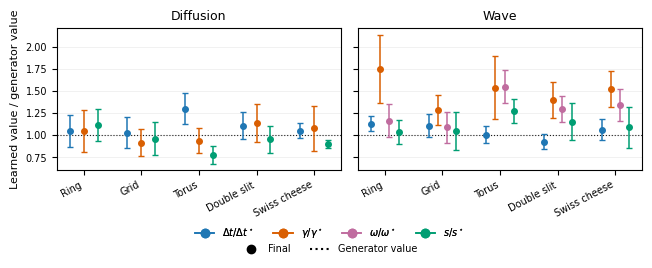

/home/tweninge/projects/ift/derived/results/figures/alternating_synthetic_recovery_physical_calibration.pdf


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.65), sharey=True)
x = np.arange(len(TOPOLOGIES))
for ax, dynamic in zip(axes, DYNAMICS):
    params = PARAMETERS_BY_DYNAMIC[dynamic]
    offsets = np.linspace(-.24, .24, len(params))
    for offset, parameter in zip(offsets, params):
        _, _, _, label, color = PARAMETERS[parameter]
        for stage, fill in [('final', color)]:
            subset = (calibration_summary.loc[(calibration_summary.dynamic == dynamic) &
                (calibration_summary.parameter == parameter) & (calibration_summary.stage == stage)]
                .set_index('topology').reindex(TOPOLOGIES))
            ax.errorbar(x + offset, subset['mean'], yerr=subset['sem'], color=color,
                        marker='o', markerfacecolor=fill, markeredgewidth=1, markersize=4,
                        capsize=2, linestyle='none', linewidth=1.1)
    ax.axhline(1, color='black', linewidth=.8, linestyle=':', zorder=0)
    #ax.set_yscale('log')
    ax.set_title(DYNAMICS_LABELS[dynamic])
    ax.set_xticks(x, [TOPOLOGY_LABELS[topology] for topology in TOPOLOGIES], rotation=28, ha='right')
    ax.grid(axis='y', alpha=.22, linewidth=.55)
axes[0].set_ylabel('Learned value / generator value')
parameter_handles = [Line2D([0], [0], color=PARAMETERS[p][4], marker='o', linewidth=1.2, label=PARAMETERS[p][3])
                     for p in ['dt', 'gamma', 'omega', 'force_scale']]
state_handles = [
    Line2D([0], [0], color='black', marker='o', markerfacecolor='black', linestyle='none', label='Final'),
    Line2D([0], [0], color='black', linestyle=':', label='Generator value'),
]
legend_one = fig.legend(handles=parameter_handles, ncol=4, loc='lower center', bbox_to_anchor=(.5, .05), frameon=False)
fig.add_artist(legend_one)
fig.legend(handles=state_handles, ncol=2, loc='lower center', bbox_to_anchor=(.5, 0.0), frameon=False)
fig.tight_layout(rect=(0, .12, 1, 1))
calibration_path = FIGURE_DIR / 'alternating_synthetic_recovery_physical_calibration.pdf'
fig.savefig(calibration_path, bbox_inches='tight')
plt.show()
print(calibration_path)


The calibration figure is intentionally scalar-by-scalar: it reports $x/x^\star$ for every physical coefficient and topology.
